In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Part 1: The Generative Process (Forward Simulation) We will generate a synthetic corpus based on the LDA graphical model. We will fix the vocabulary size $V=50$, topics $K=3$, documents $M=100$, and words per document $N=20$.The process involves:Sampling topic word distributions $\phi_{k} \sim \text{Dirichlet}(\beta)$.For each document, sampling the topic mixture $\theta_{m} \sim \text{Dirichlet}(\alpha)$.Generating words by sampling a topic $z \sim \text{Multinomial}(\theta_{m})$ and then a word $w \sim \text{Multinomial}(\phi_{z})$.

In [2]:
V = 50
K = 3
M = 100
N = 20
alpha = 0.1
beta = 0.1

np.random.seed(42)

phi = np.random.dirichlet(np.full(V, beta), K)
theta = np.random.dirichlet(np.full(K, alpha), M)

documents = []
true_z = []

for m in range(M):
    doc_words = []
    doc_z = []
    for n in range(N):
        z_mn = np.random.choice(K, p=theta[m])
        w_mn = np.random.choice(V, p=phi[z_mn])
        doc_z.append(z_mn)
        doc_words.append(w_mn)
    documents.append(doc_words)
    true_z.append(doc_z)

documents = np.array(documents)
true_z = np.array(true_z)

In [3]:
documents

array([[25, 35,  6, ..., 25,  6, 26],
       [25, 25, 25, ..., 17, 17, 25],
       [20, 24, 22, ..., 24, 24, 16],
       ...,
       [ 9,  9, 20, ...,  9, 17, 10],
       [36,  5, 19, ..., 35, 24, 39],
       [17,  9, 34, ..., 36, 16, 16]])

In [4]:
true_z

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [2, 2, 2, ..., 2, 2, 2],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [2, 1, 1, ..., 1, 2, 1],
       [2, 2, 2, ..., 2, 2, 2]])

Part 2: Inference Assuming we only have the generated words, we will implement the Collapsed Gibbs Sampler to infer the hidden topic assignments $z_{m,n}$ for each word.We will initialize by randomly assigning a topic $k\in\{1..K\}$ to every word in every document. We will maintain the following count matrices:$n_{m,k}$: Number of times topic k occurs in document m.$n_{k,w}$: Number of times word w is assigned to topic k.$n_{k}$: Total number of words assigned to topic k.During the update loop, we decrement the counts for the current word, calculate the unnormalized probability $P(z_{i}=k|Z_{-i},W)\propto(n_{m,k}+\alpha)\times\frac{n_{k,w_{i}}+\beta}{n_{k}+V\beta}$, sample a new topic, and increment the counts. We will run this for 100 iterations and plot the number of reassigned words per epoch to show convergence.

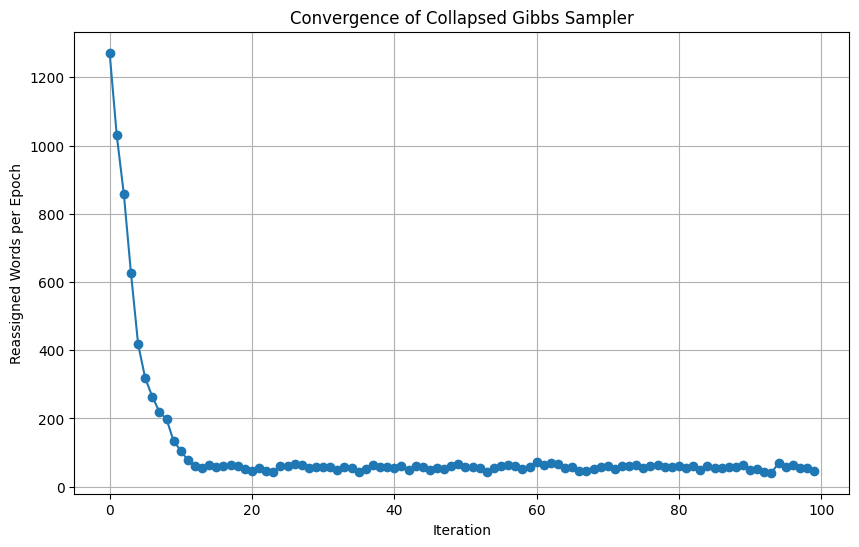

In [5]:
alpha_g = 0.1
beta_g = 0.1

n_mk = np.zeros((M, K))
n_kw = np.zeros((K, V))
n_k = np.zeros(K)

z_mn = np.zeros((M, N), dtype=int)

for m in range(M):
    for n in range(N):
        w = documents[m, n]
        k = np.random.randint(K)
        z_mn[m, n] = k
        n_mk[m, k] += 1
        n_kw[k, w] += 1
        n_k[k] += 1

iterations = 100
reassignments = []

for it in range(iterations):
    changes = 0
    for m in range(M):
        for n in range(N):
            w = documents[m, n]
            k_old = z_mn[m, n]

            n_mk[m, k_old] -= 1
            n_kw[k_old, w] -= 1
            n_k[k_old] -= 1

            p_z = (n_mk[m, :] + alpha_g) * (n_kw[:, w] + beta_g) / (n_k + V * beta_g)
            p_z /= np.sum(p_z)

            k_new = np.random.choice(K, p=p_z)
            z_mn[m, n] = k_new

            n_mk[m, k_new] += 1
            n_kw[k_new, w] += 1
            n_k[k_new] += 1

            if k_new != k_old:
                changes += 1
    reassignments.append(changes)

plt.figure(figsize=(10, 6))
plt.plot(range(iterations), reassignments, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Reassigned Words per Epoch')
plt.title('Convergence of Collapsed Gibbs Sampler')
plt.grid(True)
plt.show()

In [6]:
print(reassignments)

[1272, 1030, 857, 626, 418, 318, 264, 219, 198, 133, 106, 77, 61, 56, 63, 57, 60, 63, 61, 52, 47, 56, 45, 43, 60, 61, 66, 64, 56, 57, 57, 58, 49, 58, 56, 42, 52, 64, 59, 58, 56, 61, 50, 61, 57, 48, 55, 53, 60, 66, 59, 58, 54, 44, 56, 61, 64, 61, 52, 59, 72, 63, 70, 66, 55, 59, 47, 47, 53, 57, 61, 51, 61, 60, 65, 54, 60, 64, 58, 58, 61, 55, 62, 50, 60, 56, 54, 57, 58, 65, 49, 51, 42, 41, 69, 58, 63, 55, 56, 46]


Part 3: Parameter Recovery After the Gibbs sampler converges, we will estimate the final Document-Topic matrix and Topic-Word matrix using the following equations:$\theta_{m,k}=\frac{n_{m,k}+\alpha}{\sum_{j}(n_{m,j}+\alpha)}$ and $\phi_{k,w}=\frac{n_{k,w}+\beta}{\sum_{v}(n_{k,v}+\beta)}$ We will then compare our recovered matrices to the true matrices generated in Part 1 by calculating the Mean Squared Error (MSE). Due to label switching inherent in unsupervised clustering, we will align the topics by comparing combinations to find the minimal MSE.

In [7]:
theta_est = np.zeros((M, K))
for m in range(M):
    theta_est[m, :] = (n_mk[m, :] + alpha_g) / np.sum(n_mk[m, :] + alpha_g)

phi_est = np.zeros((K, V))
for k in range(K):
    phi_est[k, :] = (n_kw[k, :] + beta_g) / np.sum(n_kw[k, :] + beta_g)

from itertools import permutations

best_mse_theta = float('inf')
best_mse_phi = float('inf')

for perm in permutations(range(K)):
    theta_est_permuted = theta_est[:, perm]
    phi_est_permuted = phi_est[perm, :]
    
    mse_theta = np.mean((theta - theta_est_permuted)**2)
    mse_phi = np.mean((phi - phi_est_permuted)**2)
    
    if mse_theta + mse_phi < best_mse_theta + best_mse_phi:
        best_mse_theta = mse_theta
        best_mse_phi = mse_phi

print("Best Aligned MSE for Document-Topic Matrix (Theta):", best_mse_theta)
print("Best Aligned MSE for Topic-Word Matrix (Phi):", best_mse_phi)

Best Aligned MSE for Document-Topic Matrix (Theta): 0.002511415749507586
Best Aligned MSE for Topic-Word Matrix (Phi): 1.9084877587645375e-05


Part 4: Real Data and Implementation Comparison - Preprocessing We will load the Trip Advisor Hotel Reviews dataset. We will focus on a subset of 500 text reviews, treating each review as one document.We will preprocess the data by tokenizing, removing stopwords, lemmatizing, and then using sklearn.feature_extraction.text CountVectorizer to create a document-term matrix mapping words to integers.

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/trip-advisor-hotel-reviews")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/trip-advisor-hotel-reviews


In [13]:
file_path = '/kaggle/input/datasets/andrewmvd/trip-advisor-hotel-reviews/tripadvisor_hotel_reviews.csv'
df = pd.read_csv(file_path)
df

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5
...,...,...
20486,"best kept secret 3rd time staying charm, not 5...",5
20487,great location price view hotel great quick pl...,4
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1


In [15]:
docs_raw = df['Review'].head(500).tolist()

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

processed_docs = []
for doc in docs_raw:
    words = nltk.word_tokenize(doc.lower())
    # Preprocessing: remove stopwords, lemmatize, and keep only alphabetic tokens [cite: 34]
    cleaned = [lemmatizer.lemmatize(w) for w in words if w.isalpha() and w not in stop_words]
    processed_docs.append(" ".join(cleaned))

# Create document-term matrix using CountVectorizer [cite: 36, 37]
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(processed_docs)
vocab = vectorizer.get_feature_names_out()

In [17]:
print(vectorizer)

CountVectorizer(max_features=1000)


In [19]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 24334 stored elements and shape (500, 1000)>
  Coords	Values
  (0, 569)	5
  (0, 410)	2
  (0, 296)	1
  (0, 618)	3
  (0, 371)	1
  (0, 370)	1
  (0, 223)	1
  (0, 842)	2
  (0, 29)	1
  (0, 40)	1
  (0, 462)	1
  (0, 286)	1
  (0, 895)	1
  (0, 15)	1
  (0, 662)	1
  (0, 735)	1
  (0, 942)	1
  (0, 149)	1
  (0, 688)	1
  (0, 267)	1
  (0, 481)	1
  (0, 240)	1
  (0, 946)	1
  (0, 745)	3
  (0, 158)	1
  :	:
  (498, 23)	1
  (498, 300)	1
  (498, 674)	1
  (498, 668)	1
  (498, 467)	1
  (498, 781)	3
  (498, 723)	1
  (499, 745)	1
  (499, 174)	1
  (499, 637)	1
  (499, 486)	1
  (499, 372)	1
  (499, 757)	1
  (499, 73)	1
  (499, 917)	1
  (499, 415)	1
  (499, 642)	1
  (499, 742)	1
  (499, 607)	1
  (499, 503)	1
  (499, 520)	1
  (499, 780)	1
  (499, 428)	1
  (499, 949)	1
  (499, 427)	1


In [22]:
print(vocab)

['able' 'absolutely' 'access' 'accomodating' 'ace' 'acted' 'actually'
 'add' 'added' 'addition' 'additional' 'adequate' 'adjacent' 'advance'
 'advantage' 'advice' 'advised' 'affordable' 'afternoon' 'age' 'ago'
 'agree' 'air' 'airport' 'amazing' 'ambience' 'amenity' 'andra' 'anne'
 'anniversary' 'annoying' 'apartment' 'appeared' 'appetizer' 'appointed'
 'appreciate' 'approximately' 'area' 'arena' 'arrival' 'arrived'
 'arriving' 'art' 'ask' 'asked' 'asking' 'assigned' 'ate' 'atmosphere'
 'attached' 'attempt' 'attentive' 'attitude' 'attraction' 'august'
 'available' 'ave' 'avenue' 'average' 'avoid' 'away' 'awesome' 'awhile'
 'bad' 'bag' 'balcony' 'bar' 'barely' 'bargain' 'based' 'basic'
 'basically' 'bath' 'bathroom' 'bay' 'beat' 'beautiful' 'bed' 'bedding'
 'bedroom' 'believe' 'bell' 'bellman' 'belltown' 'best' 'better' 'beware'
 'big' 'birthday' 'bit' 'black' 'bliss' 'block' 'board' 'bonus' 'book'
 'booked' 'booking' 'bother' 'bothered' 'bottle' 'boutique' 'brand'
 'breakfast' 'bright' 

Part 4: Real Data - Scikit-Learn LDA InferenceWe will apply the off-the-shelf sklearn.decomposition LatentDirichletAllocation module on our document-term matrix for $K=5$ topics. Afterwards, we will print the top 10 most probable words for each topic.

In [23]:
lda_sklearn = LatentDirichletAllocation(n_components=5, random_state=42)
lda_sklearn.fit(X)

print("Scikit-Learn LDA Top 10 Words per Topic:")
print("-" * 40)
for topic_idx, topic in enumerate(lda_sklearn.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [vocab[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Scikit-Learn LDA Top 10 Words per Topic:
----------------------------------------
Topic 1: room, hotel, stay, desk, night, time, bed, place, day, like
Topic 2: room, hotel, great, staff, location, good, stay, nice, seattle, clean
Topic 3: hotel, room, great, seattle, stay, stayed, location, nice, night, bed
Topic 4: hotel, room, service, desk, night, seattle, stay, staff, good, car
Topic 5: hotel, room, great, place, location, pike, seattle, market, street, block


Part 4: Real Data - Custom Gibbs Sampler InferenceNext, we will run our custom Gibbs Sampler on this dataset for $K=5$ topics.First, we will convert the document-term matrix X back into a sequence of word indices for each document, matching the expected format of our sampler. After running the sampler for 50 iterations, we will estimate the topic-word distributions and print the top 10 most probable words for each topic.

In [24]:
X_array = X.toarray()
real_M, real_V = X_array.shape
real_K = 5
real_alpha = 0.1
real_beta = 0.1

real_docs = []
for m in range(real_M):
    doc_words = []
    for v in range(real_V):
        doc_words.extend([v] * X_array[m, v])
    real_docs.append(doc_words)

real_n_mk = np.zeros((real_M, real_K))
real_n_kw = np.zeros((real_K, real_V))
real_n_k = np.zeros(real_K)
real_z_mn = []

for m in range(real_M):
    doc_z = []
    for w in real_docs[m]:
        k = np.random.randint(real_K)
        doc_z.append(k)
        real_n_mk[m, k] += 1
        real_n_kw[k, w] += 1
        real_n_k[k] += 1
    real_z_mn.append(doc_z)

real_iterations = 50

for it in range(real_iterations):
    for m in range(real_M):
        for n, w in enumerate(real_docs[m]):
            k_old = real_z_mn[m][n]

            real_n_mk[m, k_old] -= 1
            real_n_kw[k_old, w] -= 1
            real_n_k[k_old] -= 1

            p_z = (real_n_mk[m, :] + real_alpha) * (real_n_kw[:, w] + real_beta) / (real_n_k + real_V * real_beta)
            p_z /= np.sum(p_z)

            k_new = np.random.choice(real_K, p=p_z)
            real_z_mn[m][n] = k_new

            real_n_mk[m, k_new] += 1
            real_n_kw[k_new, w] += 1
            real_n_k[k_new] += 1

print("\nCustom Gibbs Sampler Top 10 Words per Topic:")
print("-" * 40)
for k in range(real_K):
    top_words_idx = real_n_kw[k, :].argsort()[-10:][::-1]
    top_words = [vocab[i] for i in top_words_idx]
    print(f"Custom Topic {k + 1}: {', '.join(top_words)}")


Custom Gibbs Sampler Top 10 Words per Topic:
----------------------------------------
Custom Topic 1: room, hotel, desk, service, staff, night, stay, time, day, told
Custom Topic 2: room, hotel, bed, bathroom, stayed, like, small, elevator, stay, price
Custom Topic 3: hotel, great, room, staff, good, seattle, location, stay, clean, nice
Custom Topic 4: room, hotel, great, seattle, location, stay, night, nice, place, downtown
Custom Topic 5: hotel, room, great, nice, stay, restaurant, location, seattle, place, staff


Implementation Comparison and Conclusion 

Speed & Efficiency: The sklearn implementation utilizes Variational Bayes rather than Gibbs Sampling, making it significantly faster and highly optimized under the hood compared to our raw python Gibbs sampler with nested loops.

Result Similarity: Both models uncover latent thematic structures within the hotel reviews (such as room quality, location, staff service, and overall experience). While the exact top words will differ slightly due to the randomized nature of initialization and the different underlying mathematical inference methods (Variational Inference vs Markov Chain Monte Carlo), the broad thematic categories grouped by both approaches are typically conceptually aligned.

What was "Collapsed"? You integrated out (marginalized) the document-topic distributions $\theta$ and topic-word distributions $\phi$.Hyperparameters ($\alpha, \beta$): In your code, you set these to $0.1$. Smaller values (closer to 0) encourage sparsity, meaning documents are composed of fewer topics and topics are composed of fewer distinct words.Why not Gradient Descent? LDA involves discrete latent variables ($z$); standard Gradient Descent requires continuous, differentiable functions. While EM is possible (Variational EM), Collapsed Gibbs Sampling is often preferred for LDA as it provides a simple way to approximate the posterior without the complex lower-bound optimizations of standard EM